In [4]:
!pip uninstall -y lambeq discopy

In [5]:
!pip install lambeq==0.3.0

  Using cached lambeq-0.3.0-py3-none-any.whl.metadata (5.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.1/126.1 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.3/364.3 kB 21.5 MB/s eta 0:00:00
  Created wheel for discopy: filename=discopy-0.5.1.2-py3-none-any.whl size=111871 sha256=2ad33462d318c66a4725a8545fca29c0b206e989e9266eb152e56bf308f0642b
  Stored in directory: /root/.cache/pip/wheels/2b/f6/95/060a420333f170451271cb7071eb6013637dc2a90182ef12c3
Successfully built discopy


In [9]:
!pip install discopy

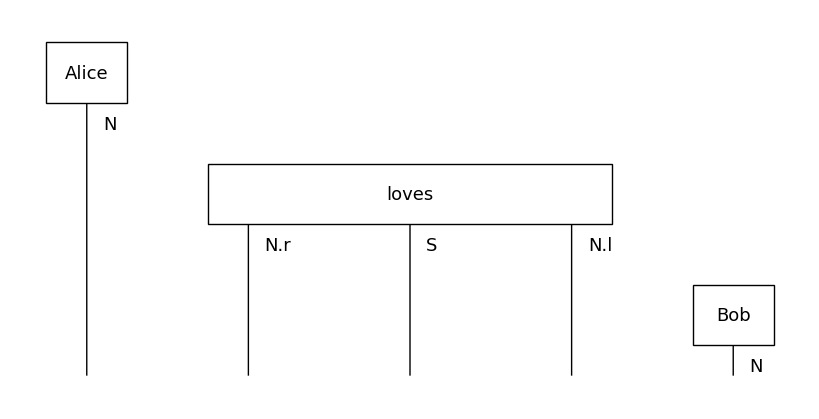

In [28]:
from discopy.grammar.pregroup import Word, Ty

# Types
N = Ty('N')
S = Ty('S')

# Words
Alice = Word('Alice', N)
loves = Word('loves', N.r @ S @ N.l)
Bob = Word('Bob', N)

# Build sentence
sentence = Alice @ loves @ Bob

# Apply reduction (NEW method)
diagram = sentence.normal_form()

#diagram.draw(figsize=(5, 5), fontsize=12)
diagram.draw(figsize=(8,4), fontsize=13)



--- Alice loves Bob ---
Original: Alice >> Id(N) @ loves >> Id(N @ N.r @ S @ N.l) @ Bob
Reduced: Alice >> Id(N) @ loves >> Id(N @ N.r @ S @ N.l) @ Bob


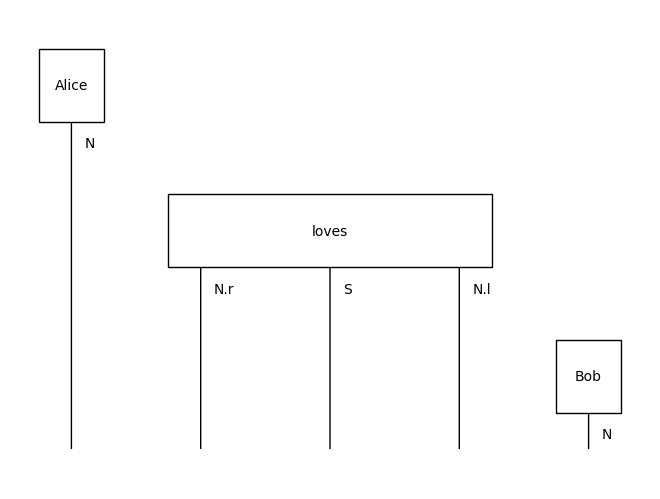


--- Alice runs ---
Original: Alice >> Id(N) @ runs
Reduced: Alice >> Id(N) @ runs


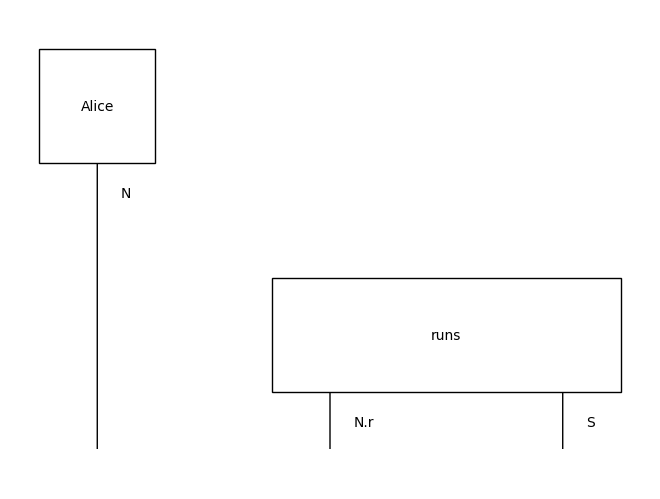


--- smart Students ---
Original: smart >> Id(N @ N.l) @ Students
Reduced: smart >> Id(N @ N.l) @ Students


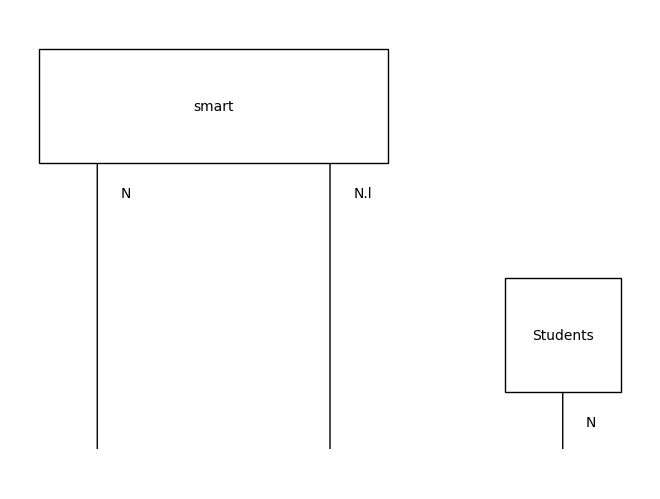


--- the Students ---
Original: the >> Id(N @ N.l) @ Students
Reduced: the >> Id(N @ N.l) @ Students


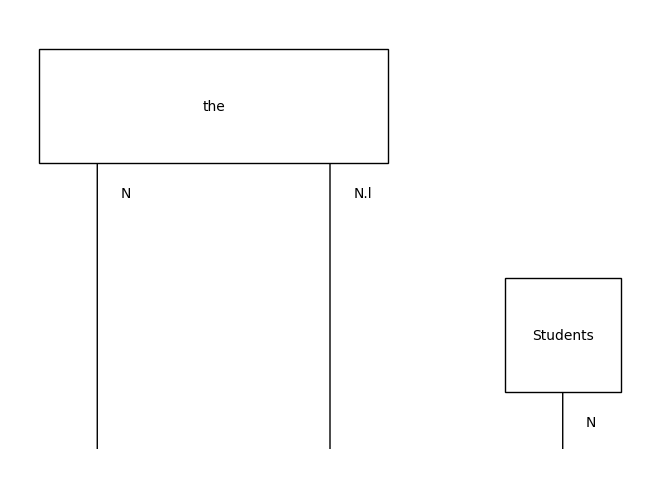


--- smart Students run ---
Original: smart >> Id(N @ N.l) @ Students >> Id(N @ N.l @ N) @ runs
Reduced: smart >> Id(N @ N.l) @ Students >> Id(N @ N.l @ N) @ runs


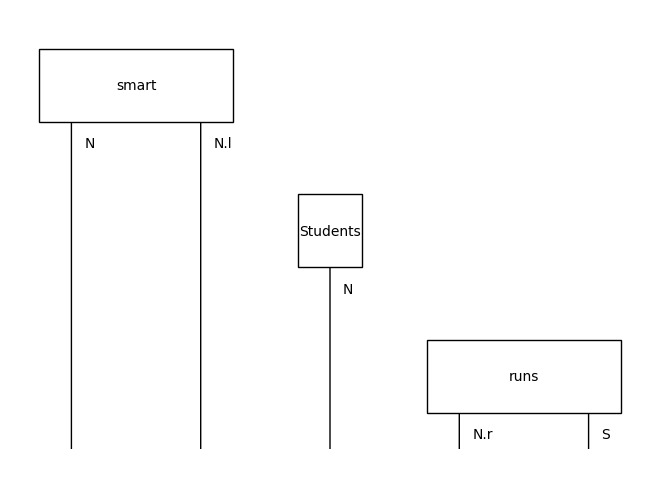

In [15]:
# Install if needed (Colab)
# !pip install discopy

from discopy.grammar.pregroup import Word, Ty

# =========================
# 1. DEFINE TYPES
# =========================
N = Ty('N')   # Noun
S = Ty('S')   # Sentence

# =========================
# 2. WORD LIBRARY
# =========================

# Nouns
Alice = Word('Alice', N)
Bob = Word('Bob', N)
Students = Word('Students', N)

# Verbs
loves = Word('loves', N.r @ S @ N.l)        # transitive
runs = Word('runs', N.r @ S)                # intransitive

# Adjectives
smart = Word('smart', N @ N.l)
happy = Word('happy', N @ N.l)

# Determiners
the = Word('the', N @ N.l)

# =========================
# 3. SENTENCE GENERATORS
# =========================

def transitive_sentence(subj, verb, obj):
    """Alice loves Bob"""
    return subj @ verb @ obj

def intransitive_sentence(subj, verb):
    """Alice runs"""
    return subj @ verb

def adjective_noun(adj, noun):
    """smart Alice"""
    return adj @ noun

def determiner_noun(det, noun):
    """the students"""
    return det @ noun

def adj_noun_verb(adj, noun, verb):
    """smart students run"""
    return adj @ noun @ verb

# =========================
# 4. PROCESS + DRAW
# =========================

def process_sentence(name, sentence):
    print(f"\n--- {name} ---")

    # Reduce (grammar simplification)
    reduced = sentence.normal_form()

    print("Original:", sentence)
    print("Reduced:", reduced)

    # Draw diagram
    reduced.draw()

# =========================
# 5. RUN EXAMPLES
# =========================

# 1. Simple transitive
s1 = transitive_sentence(Alice, loves, Bob)

# 2. Intransitive
s2 = intransitive_sentence(Alice, runs)

# 3. Adjective + noun
s3 = adjective_noun(smart, Students)

# 4. Determiner + noun
s4 = determiner_noun(the, Students)

# 5. Full sentence with adjective
s5 = adj_noun_verb(smart, Students, runs)

# =========================
# 6. DISPLAY ALL
# =========================

process_sentence("Alice loves Bob", s1)
process_sentence("Alice runs", s2)
process_sentence("smart Students", s3)
process_sentence("the Students", s4)
process_sentence("smart Students run", s5)